In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import seaborn as sns
import statsmodels.stats.outliers_influence as outliers_influence
from statsmodels.graphics.gofplots import qqplot, qqline
import itertools
from tqdm import tnrange

# Question One

In [3]:
df = pd.read_csv('bonds.txt', sep = '\t')

## Part 1

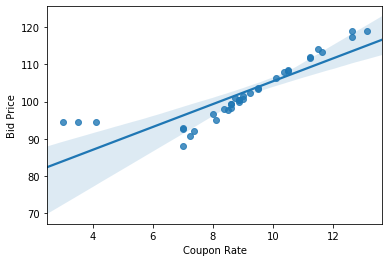

In [4]:
sns.regplot(x = 'CouponRate', y = 'BidPrice', data = df)
plt.xlabel("Coupon Rate")
plt.ylabel("Bid Price")
plt.show()

There is a clear linear relationship between bid price and coupon rate, except for the three extreme observations on the left side of the plot.

## Part 2

In [5]:
holdlm = sm.OLS.from_formula(formula="BidPrice ~ CouponRate",data=df).fit()
holdlm.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               BidPrice   R-squared:                       0.752
Model:                            OLS   Adj. R-squared:                  0.744
Method:                 Least Squares   F-statistic:                     99.87
Date:                Tue, 20 Oct 2020   Prob (F-statistic):           1.64e-11
Time:                        19:51:30   Log-Likelihood:                -98.656
No. Observations:                  35   AIC:                             201.3
Df Residuals:                      33   BIC:                             204.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     74.7866      2.827     26.458      0.000      69.036      80.537
CouponRate     3.0661      0.307      9.994      0.000       2.442       3.690
==============================================================================
Omnibus:                        3.313   Durbin-Watson:                   1.827
Prob(Omnibus):                  0.191   Jarque-Bera (JB):                2.262
Skew:                           0.607   Prob(JB):                        0.323
Kurtosis:                       3.276   Cond. No.                         37.3
==============================================================================

Warnings:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

## Part 3

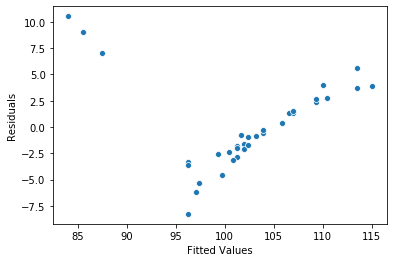

In [6]:
sns.scatterplot(holdlm.fittedvalues,holdlm.resid)
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.show()

There is a clear pattern in this plot. We are not seeing the random scatter that is characteristic of well-fitting regression models. This is just confirming the lack of fit that was clear in the original scatter plot.

## Part 4

The 95% confidence interval for $\beta_1$ is reported in the output above as $(2.442, 3.690)$.

We could also calculate this using the appropriate point from the t distribution with $n-2=33$ degrees of freedom.

In [7]:
from scipy.stats import t
t.ppf(0.975,33)

2.0345152974493383

So, the interval goes from $3.07 - 2.03 \times 0.31$ to $3.07 + 2.03 \times 0.31$, since the standard error on $\hat{\beta_1)$ is 0.31, from the table above.

This interval should not be trusted, because the model is clearly a poor fit.

# Question Two

## Part 1

In [8]:
data = pd.read_csv("http://www.stat.cmu.edu/~cschafer/MSCF/bonddata.txt")

In [9]:
data.head()

,id,bond_id,trade_price,weight,current_coupon,time_to_maturity,is_callable,reporting_delay,trade_size,trade_type,...,received_time_diff_last9,trade_price_last9,trade_size_last9,trade_type_last9,curve_based_price_last9,received_time_diff_last10,trade_price_last10,trade_size_last10,trade_type_last10,curve_based_price_last10
0,10,1,126.268,7.616851,5.950,25.940349,0,12.540,150000.0,3,...,2862729,128.596,120000.0,2,127.561201,3621492,129.089,200000.0,2,129.435587
1,38,2,101.009,0.018373,3.550,0.326392,0,9.327,450000.0,3,...,532644,101.086,500000.0,2,101.103180,538510,101.070,25000.0,2,101.102243
2,336,3,108.144,3.537380,4.200,2.340601,0,0.102,160000.0,4,...,96293,107.917,400000.0,2,107.874965,96293,107.917,400000.0,4,107.874965
3,781,4,116.953,0.402523,4.875,7.367653,0,52.093,10000.0,4,...,92559,115.924,10000.0,2,116.160420,97177,116.458,2000.0,3,116.342802
4,1172,14,133.210,0.210685,10.750,4.159301,0,13.722,25000.0,4,...,6400208,127.500,25000.0,2,131.066998,6400208,127.500,25000.0,4,131.066998


In [10]:
data.shape

(1620, 61)

In [11]:
data = data.drop(['id', 'bond_id'], axis=1)

In [12]:
data['is_callable'] = data['is_callable'].astype('category').cat.as_unordered()
data['trade_type'] = data['trade_type'].astype('category').cat.as_unordered()
data['trade_type_last1'] = data['trade_type_last1'].astype('category').cat.as_unordered()
data['trade_type_last2'] = data['trade_type_last2'].astype('category').cat.as_unordered()
data['trade_type_last3'] = data['trade_type_last3'].astype('category').cat.as_unordered()
data['trade_type_last4'] = data['trade_type_last4'].astype('category').cat.as_unordered()
data['trade_type_last5'] = data['trade_type_last5'].astype('category').cat.as_unordered()
data['trade_type_last6'] = data['trade_type_last6'].astype('category').cat.as_unordered()
data['trade_type_last7'] = data['trade_type_last7'].astype('category').cat.as_unordered()
data['trade_type_last8'] = data['trade_type_last8'].astype('category').cat.as_unordered()
data['trade_type_last9'] = data['trade_type_last9'].astype('category').cat.as_unordered()
data['trade_type_last10'] = data['trade_type_last10'].astype('category').cat.as_unordered()

## Part 2

In [24]:
df = pd.get_dummies(data,drop_first=True)

In [25]:
df_1 = sm.add_constant(df)

In [26]:
full_model = sm.OLS(df['trade_price'], df_1.drop(['trade_price'], axis=1)).fit()

In [27]:
full_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            trade_price   R-squared:                       0.980
Model:                            OLS   Adj. R-squared:                  0.979
Method:                 Least Squares   F-statistic:                     1113.
Date:                Tue, 20 Oct 2020   Prob (F-statistic):               0.00
Time:                        20:06:05   Log-Likelihood:                -3076.8
No. Observations:                1620   AIC:                             6294.
Df Residuals:                    1550   BIC:                             6671.
Df Model:                          69                                         
Covariance Type:            nonrobust                                         
=============================================================================================
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                         0.8378      0.553      1.515      0.130      -0.247       1.923
weight                        0.0303      0.017      1.796      0.073      -0.003       0.063
current_coupon                0.0263      0.030      0.870      0.385      -0.033       0.085
time_to_maturity             -0.0013      0.006     -0.217      0.828      -0.013       0.010
reporting_delay           -1.648e-06   1.25e-06     -1.323      0.186   -4.09e-06    7.95e-07
trade_size                 1.037e-07   6.09e-08      1.702      0.089   -1.58e-08    2.23e-07
curve_based_price             0.3869      0.041      9.425      0.000       0.306       0.467
received_time_diff_last1   -2.07e-07   1.48e-07     -1.398      0.162   -4.97e-07    8.34e-08
trade_price_last1             0.4124      0.037     11.283      0.000       0.341       0.484
trade_size_last1          -7.236e-08   6.22e-08     -1.163      0.245   -1.94e-07    4.97e-08
curve_based_price_last1      -0.0259      0.069     -0.378      0.706      -0.160       0.109
received_time_diff_last2   -4.04e-08   1.28e-07     -0.315      0.753   -2.92e-07    2.12e-07
trade_price_last2             0.0267      0.040      0.669      0.504      -0.052       0.105
trade_size_last2           3.671e-08   6.64e-08      0.553      0.580   -9.35e-08    1.67e-07
curve_based_price_last2      -0.0574      0.072     -0.802      0.423      -0.198       0.083
received_time_diff_last3   1.481e-08   1.31e-07      0.113      0.910   -2.42e-07    2.72e-07
trade_price_last3             0.0456      0.037      1.219      0.223      -0.028       0.119
trade_size_last3          -2.987e-08   6.45e-08     -0.463      0.643   -1.56e-07    9.67e-08
curve_based_price_last3      -0.1502      0.073     -2.065      0.039      -0.293      -0.007
received_time_diff_last4  -7.693e-08   1.29e-07     -0.597      0.550    -3.3e-07    1.76e-07
trade_price_last4             0.0877      0.035      2.496      0.013       0.019       0.157
trade_size_last4          -6.019e-08    6.2e-08     -0.971      0.332   -1.82e-07    6.14e-08
curve_based_price_last4       0.2361      0.076      3.087      0.002       0.086       0.386
received_time_diff_last5  -9.797e-08   1.25e-07     -0.786      0.432   -3.42e-07    1.47e-07
trade_price_last5             0.0405      0.037      1.097      0.273      -0.032       0.113
trade_size_last5           5.961e-08   6.62e-08      0.900      0.368   -7.03e-08    1.89e-07
curve_based_price_last5      -0.2658      0.074     -3.571      0.000      -0.412      -0.120
received_time_diff_last6   1.976e-07   1.12e-07      1.758      0.079   -2.29e-08    4.18e-07
trade_price_last6            -0.0390      0.037     -1.067      0.286      -0.111       0.033
trade_size_last6          -3.979e-10   6.76e-08     -0.006      0.995   -1.

Text(0, 0.5, 'Residuals')

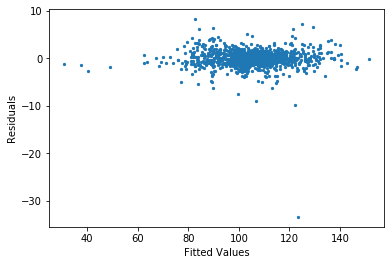

In [28]:
plt.scatter(full_model.fittedvalues, full_model.resid, s=5)
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")

With the exception of one outlier, the model fit seems decent.

## Part 3

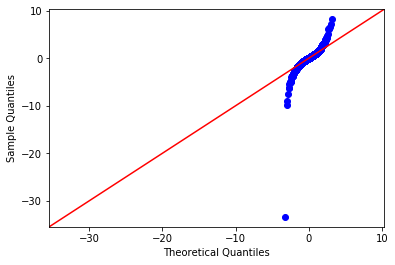

In [29]:
qqplot(full_model.resid, line='45')
plt.show()

The normal Q-Q plot assesses whether the residuals appear normally distributed. These residuals are very heavy-tailed.

## Part 4

In [30]:
X = df.drop(['trade_price'], axis=1)
features_chosen = []
remaining_features = list(X.columns.values)
best_AIC = np.inf

for k in tnrange(1, len(X.columns)+1):
    add_feature = False
    
    for combo in itertools.combinations(remaining_features, 1):
        X_with_ones = sm.add_constant(X[list(combo) + features_chosen])
        model = sm.OLS(df['trade_price'], exog=X_with_ones).fit()
        this_AIC = model.aic

        if this_AIC < best_AIC:
            add_feature = True
            best_AIC = this_AIC
            best_feature = combo[0]
    
    if add_feature:
        features_chosen.append(best_feature)
        remaining_features.remove(best_feature)

/Users/chadschafer/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:6: TqdmDeprecationWarning: Please use `tqdm.notebook.trange` instead of `tqdm.tnrange`
  


In [31]:
features_chosen

['trade_price_last1',
 'curve_based_price',
 'trade_type_3',
 'trade_price_last7',
 'trade_type_4',
 'trade_price_last10',
 'trade_price_last4',
 'curve_based_price_last5',
 'trade_type_last1_3',
 'trade_type_last4_3',
 'trade_type_last4_4',
 'trade_type_last1_4',
 'trade_price_last9',
 'trade_type_last5_3',
 'curve_based_price_last2',
 'curve_based_price_last4',
 'curve_based_price_last3',
 'received_time_diff_last10',
 'trade_price_last3',
 'is_callable_1',
 'reporting_delay']

In [32]:
aic_X = df[features_chosen]
aic_X_with_ones = sm.add_constant(aic_X)
aic_model = sm.OLS(df['trade_price'], aic_X_with_ones, axis=1).fit()

In [33]:
aic_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            trade_price   R-squared:                       0.980
Model:                            OLS   Adj. R-squared:                  0.980
Method:                 Least Squares   F-statistic:                     3689.
Date:                Tue, 20 Oct 2020   Prob (F-statistic):               0.00
Time:                        20:06:47   Log-Likelihood:                -3094.0
No. Observations:                1620   AIC:                             6232.
Df Residuals:                    1598   BIC:                             6350.
Df Model:                          21                                         
Covariance Type:            nonrobust                                         
=============================================================================================
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                         0.9405      0.487      1.932      0.054      -0.015       1.896
trade_price_last1             0.4323      0.027     15.727      0.000       0.378       0.486
curve_based_price             0.3826      0.033     11.460      0.000       0.317       0.448
trade_type_3                  1.6097      0.110     14.651      0.000       1.394       1.825
trade_price_last7             0.1175      0.023      5.043      0.000       0.072       0.163
trade_type_4                  0.8109      0.100      8.135      0.000       0.615       1.006
trade_price_last10            0.0473      0.026      1.824      0.068      -0.004       0.098
trade_price_last4             0.1036      0.031      3.398      0.001       0.044       0.163
curve_based_price_last5      -0.1997      0.050     -3.967      0.000      -0.298      -0.101
trade_type_last1_3           -0.4551      0.116     -3.924      0.000      -0.683      -0.228
trade_type_last4_3           -0.4250      0.122     -3.472      0.001      -0.665      -0.185
trade_type_last4_4           -0.2051      0.104     -1.971      0.049      -0.409      -0.001
trade_type_last1_4           -0.2395      0.106     -2.255      0.024      -0.448      -0.031
trade_price_last9             0.0600      0.027      2.185      0.029       0.006       0.114
trade_type_last5_3           -0.1577      0.088     -1.787      0.074      -0.331       0.015
curve_based_price_last2      -0.0653      0.053     -1.242      0.215      -0.168       0.038
curve_based_price_last4       0.2087      0.074      2.805      0.005       0.063       0.355
curve_based_price_last3      -0.1456      0.070     -2.082      0.038      -0.283      -0.008
received_time_diff_last10 -3.636e-08   2.06e-08     -1.763      0.078   -7.68e-08    4.08e-09
trade_price_last3             0.0472      0.031      1.544      0.123      -0.013       0.107
is_callable_1                 0.1830      0.119      1.536      0.125      -0.051       0.417
reporting_delay           -1.737e-06   1.23e-06     -1.417      0.157   -4.14e-06    6.68e-07
==============================================================================
Omnibus:                     1926.296   Durbin-Watson:                   1.977
Prob(Omnibus):                  0.000   Jarque-Bera (JB):           904167.893
Skew:                          -5.516   Prob(JB):                         0.00
Kurtosis:                     118.210   Cond. No.                     3.35e+07
==============================================================================

Warnings:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 3.35e+07. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

## Part 5

In [34]:
def calc_PRESS(model):
    levs = outliers_influence.OLSInfluence(model).hat_matrix_diag
    PRESS = ((model.resid / (1 - levs))**2).sum()
    return PRESS

In [35]:
X = df.drop(['trade_price'], axis=1)
features_chosen = []
remaining_features = list(X.columns.values)
best_PRESS = np.inf

for k in tnrange(1, len(X.columns)+1):
    add_feature = False
    
    for combo in itertools.combinations(remaining_features, 1):
        X_with_ones = sm.add_constant(X[list(combo) + features_chosen])
        model = sm.OLS(df['trade_price'], exog=X_with_ones).fit()
        this_PRESS = calc_PRESS(model)

        if this_PRESS < best_PRESS:
            add_feature = True
            best_PRESS = this_PRESS
            best_feature = combo[0]
    
    if add_feature:
        features_chosen.append(best_feature)
        remaining_features.remove(best_feature)

/Users/chadschafer/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:6: TqdmDeprecationWarning: Please use `tqdm.notebook.trange` instead of `tqdm.tnrange`
  


In [36]:
features_chosen

['trade_price_last1',
 'curve_based_price',
 'trade_type_3',
 'trade_price_last7',
 'trade_type_4',
 'trade_price_last10',
 'trade_type_last1_3',
 'curve_based_price_last5',
 'trade_price_last4',
 'trade_type_last4_3',
 'trade_type_last1_4',
 'trade_type_last4_4',
 'trade_size_last7',
 'is_callable_1',
 'trade_size',
 'received_time_diff_last10',
 'trade_price_last9',
 'trade_type_last5_3',
 'reporting_delay']

In [37]:
press_X = df[features_chosen]
press_X_with_ones = sm.add_constant(press_X)
press_model = sm.OLS(df['trade_price'], press_X_with_ones, axis=1).fit()

In [38]:
press_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            trade_price   R-squared:                       0.980
Model:                            OLS   Adj. R-squared:                  0.979
Method:                 Least Squares   F-statistic:                     4059.
Date:                Tue, 20 Oct 2020   Prob (F-statistic):               0.00
Time:                        20:25:19   Log-Likelihood:                -3098.6
No. Observations:                1620   AIC:                             6237.
Df Residuals:                    1600   BIC:                             6345.
Df Model:                          19                                         
Covariance Type:            nonrobust                                         
=============================================================================================
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                         0.8941      0.488      1.832      0.067      -0.063       1.851
trade_price_last1             0.4299      0.026     16.811      0.000       0.380       0.480
curve_based_price             0.3542      0.028     12.549      0.000       0.299       0.410
trade_type_3                  1.5927      0.110     14.468      0.000       1.377       1.809
trade_price_last7             0.1187      0.023      5.097      0.000       0.073       0.164
trade_type_4                  0.8213      0.100      8.179      0.000       0.624       1.018
trade_price_last10            0.0579      0.026      2.255      0.024       0.008       0.108
trade_type_last1_3           -0.4458      0.115     -3.887      0.000      -0.671      -0.221
curve_based_price_last5      -0.1637      0.029     -5.635      0.000      -0.221      -0.107
trade_price_last4             0.1393      0.025      5.648      0.000       0.091       0.188
trade_type_last4_3           -0.4683      0.121     -3.855      0.000      -0.707      -0.230
trade_type_last1_4           -0.2255      0.106     -2.127      0.034      -0.433      -0.018
trade_type_last4_4           -0.2177      0.104     -2.090      0.037      -0.422      -0.013
trade_size_last7          -6.764e-08   5.28e-08     -1.281      0.200   -1.71e-07     3.6e-08
is_callable_1                 0.2015      0.120      1.684      0.092      -0.033       0.436
trade_size                 7.804e-08    5.7e-08      1.370      0.171   -3.37e-08     1.9e-07
received_time_diff_last10 -3.322e-08   2.06e-08     -1.609      0.108   -7.37e-08    7.28e-09
trade_price_last9             0.0529      0.027      1.938      0.053      -0.001       0.106
trade_type_last5_3           -0.1604      0.088     -1.813      0.070      -0.334       0.013
reporting_delay           -1.692e-06   1.23e-06     -1.378      0.168    -4.1e-06    7.16e-07
==============================================================================
Omnibus:                     1935.641   Durbin-Watson:                   1.979
Prob(Omnibus):                  0.000   Jarque-Bera (JB):           914854.958
Skew:                          -5.566   Prob(JB):                         0.00
Kurtosis:                     118.886   Cond. No.                     3.36e+07
==============================================================================

Warnings:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 3.36e+07. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

The model fit with PRESS selects largely the same subset of covariates, with minor differences. The order in which different covariates are added also changes. Both AIC and PRESS forward selection models are about the same size.

## Comment

It would make a lot of sense to revisit this regression problem in light of the ideas discussed in Part 8 of the lecture notes. In particular, some of the predictors are highly skewed, and would likely benefit from a log transformation. For example...

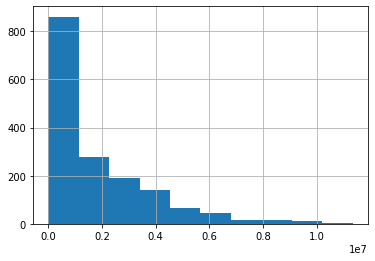

In [39]:
data['received_time_diff_last9'].hist()